A. Exploratory Analysis & Insights
Using SQL and/or Python (pandas, Polars, etc.):
1. Compute and explore:
• Monthly GMV by city and category.
• Monthly count of orders and unique active customers.
• Monthly repeat purchase rate (customers with ≥2 delivered orders so far).
• Share of delayed orders by city and carrier.
2. In a short write-up (max ~1 page in README or markdown):
• Highlight 3–5 key findings you think leadership should know (e.g., segments, lanes, or carriers that are
problematic or promising).

• Call out any assumptions you made where the data was ambiguous.

Assumpstions:

-- GMV is being calculated on the listed price by seller , not on the discounted price.


-- in the whole problem statement 4 city type is mentioned , customer's city, seller's city, shipping from city , shipping to city , though in most of the cases customer's city == shipping to city and seller's city == shipping from city still it is not gurrentted always ,
so i am considering customer's city here for first question

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:


BASE = os.path.join(os.getcwd(), "..")  # project root
order_items = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "order_items_clean.parquet"))
customers = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "customers_cleaned.parquet"))
orders = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "orders_clean.parquet"))
products = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "products_cleaned.parquet"))
sellers = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "sellers_clean.parquet"))
shipments = pd.read_parquet(os.path.join(BASE, "Data", "preprocessed", "shipment_clean.parquet"))





In [3]:
#monthly GMV by city and category

order_items_1 = order_items[["order_id","product_id","GMV","order_item_id"]]
orders_1 = orders[["order_id","customer_id","created_at","order_year","order_monthname","order_month","status"]]
#shipment_1 = shipment[["order_id","ship_from_city","ship_to_city"]]
product_1 = products[["product_id","category"]]
customer_1 = customers[["customer_id","city"]]



In [4]:
# Step 1 - order_items + product (get category)
order_items_2 = pd.merge(order_items_1, product_1, on="product_id", how="left")
assert order_items_2.shape[0] == order_items_1.shape[0]

# Step 2 - orders + customer (get city)
orders_2 = pd.merge(orders_1, customer_1, on="customer_id", how="left")
assert orders_2.shape[0] == orders_1.shape[0]


# Step 3 - merge both on order_id
final_df = pd.merge(order_items_2, orders_2, on="order_id", how="left")
assert final_df.shape[0] == order_items_2.shape[0]



In [5]:
# Check duplicates in final_df
print(f"final_df shape          : {final_df.shape}")
print(f"unique order_item_id    : {final_df['order_item_id'].nunique()}")
print(f"unique order_id         : {final_df['order_id'].nunique()}")
print(f"unique customer_id      : {final_df['customer_id'].nunique()}")

# Check if any order_item_id is duplicated
dup_items = final_df.duplicated(subset="order_item_id").sum()
print(f"\nDuplicate order_item_id : {dup_items}")

# Check if merge inflated rows
print(f"\norder_items_2 rows : {order_items_2.shape[0]}")
print(f"final_df rows      : {final_df.shape[0]}")
print(f"Difference         : {final_df.shape[0] - order_items_2.shape[0]}")

final_df shape          : (169929, 12)
unique order_item_id    : 169929
unique order_id         : 100000
unique customer_id      : 23940

Duplicate order_item_id : 0

order_items_2 rows : 169929
final_df rows      : 169929
Difference         : 0


In [6]:
print(orders_2.duplicated(subset="order_id").sum())

0


In [7]:
# Step 4 - Monthly GMV by city and category
monthly_gmv = (final_df.groupby(["order_year", "order_month", 
                                  "order_monthname", "city", "category"])["GMV"]
               .sum()
               .reset_index()
               .sort_values(["order_year", "order_month"]))

#monthly_gmv




In [8]:
# 1. Overall GMV trend
monthly_gmv_trend = monthly_gmv.groupby(["order_year","order_month","order_monthname"])["GMV"].sum().reset_index()

In [9]:
# H2 comparison (common months Jul-Dec)

h2_months = [7, 8, 9, 10, 11, 12]

h2_data = (monthly_gmv_trend[monthly_gmv_trend["order_month"].isin(h2_months)]
           .pivot(index="order_monthname", columns="order_year", values="GMV")
           .reindex(["July","August","September","October","November","December"]))

# YoY change
h2_data["YoY_change"]  = h2_data[2025] - h2_data[2024]
h2_data["YoY_pct"]     = ((h2_data[2025] - h2_data[2024]) / h2_data[2024] * 100).round(2)

print("H2 GMV Comparison (2024 vs 2025)")
print(h2_data)

# For 2025 full year month contribution within 2025 only
gmv_2025 = monthly_gmv_trend[monthly_gmv_trend["order_year"] == 2025].copy()
gmv_2025["pct_of_2025"] = ((gmv_2025["GMV"] / gmv_2025["GMV"].sum()) * 100).round(2)

print("\n2025 Monthly GMV Contribution")
print(gmv_2025[["order_monthname","GMV","pct_of_2025"]])

H2 GMV Comparison (2024 vs 2025)
order_year              2024         2025  YoY_change  YoY_pct
order_monthname                                               
July             194561564.0  189565741.0  -4995823.0    -2.57
August           194832277.0  195667973.0    835696.0     0.43
September        186364791.0  185108741.0  -1256050.0    -0.67
October          190639228.0  194416855.0   3777627.0     1.98
November         184720074.0  191826945.0   7106871.0     3.85
December         186549751.0  181555592.0  -4994159.0    -2.68

2025 Monthly GMV Contribution
   order_monthname          GMV  pct_of_2025
6          January  189911685.0         8.42
7         February  176686798.0         7.84
8            March  192612052.0         8.54
9            April  180771429.0         8.02
10             May  188407669.0         8.36
11            June  187795184.0         8.33
12            July  189565741.0         8.41
13          August  195667973.0         8.68
14       September  1851087

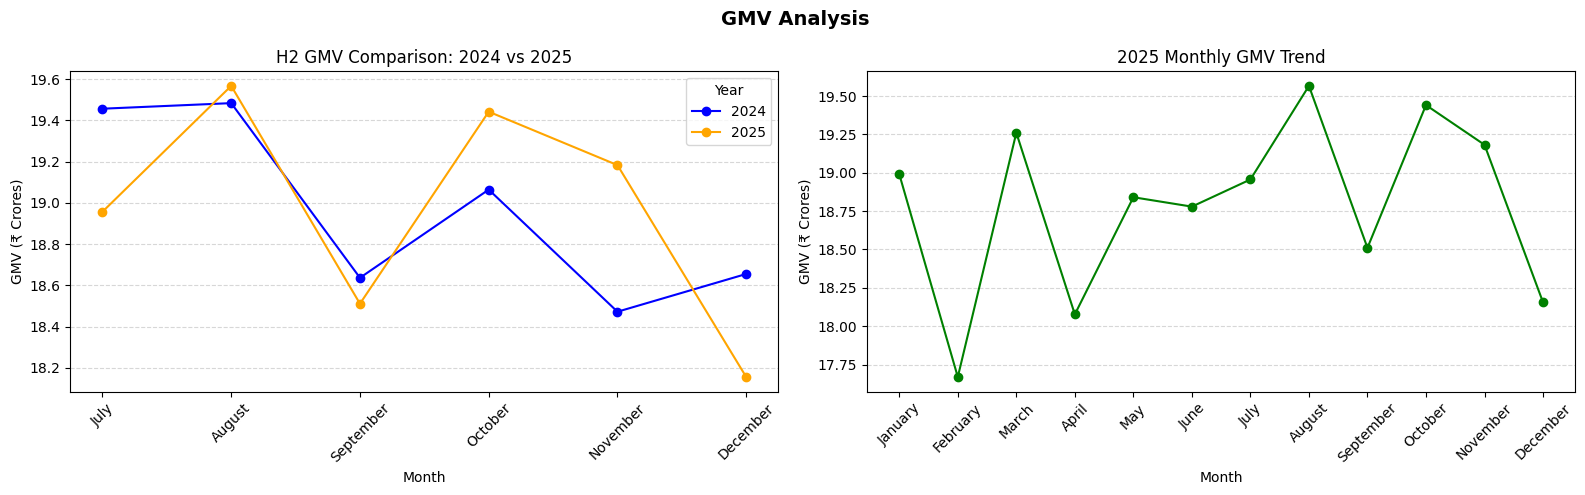

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 - H2 YoY Comparison
h2_months = ["July","August","September","October","November","December"]
axes[0].plot(h2_months, h2_data[2024]/1e7, marker="o", color="blue",   label="2024")
axes[0].plot(h2_months, h2_data[2025]/1e7, marker="o", color="orange", label="2025")
axes[0].set_title("H2 GMV Comparison: 2024 vs 2025")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("GMV (₹ Crores)")
axes[0].legend(title="Year")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2 - 2025 Full Year Monthly GMV
axes[1].plot(gmv_2025["order_monthname"], gmv_2025["GMV"]/1e7, 
             marker="o", color="green")
axes[1].set_title("2025 Monthly GMV Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("GMV (₹ Crores)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("GMV Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
monthly_gmv_2025 = monthly_gmv[monthly_gmv["order_year"]==2025]

In [12]:
# 2. GMV by city
#monthly_gmv_2025 = monthly_gmv[monthly_gmv["order_year"]==2025]
gmv_city_trend = monthly_gmv.groupby(["city"])["GMV"].sum().sort_values(ascending=False).reset_index()



In [13]:
#gmv_city_trend

In [14]:
# H2 months only
h2_months = [7, 8, 9, 10, 11, 12]

# H2 2024 city GMV
h2_2024_city = (final_df[(final_df["order_year"] == 2024) & 
                          (final_df["order_month"].isin(h2_months))]
                .groupby("city")["GMV"]
                .sum()
                .reset_index()
                .rename(columns={"GMV":"GMV_2024"}))

# H2 2025 city GMV
h2_2025_city = (final_df[(final_df["order_year"] == 2025) & 
                          (final_df["order_month"].isin(h2_months))]
                .groupby("city")["GMV"]
                .sum()
                .reset_index()
                .rename(columns={"GMV":"GMV_2025"}))

# Merge and calculate YoY
city_compare = pd.merge(h2_2024_city, h2_2025_city, on="city")
city_compare["YoY_change_cr"] = ((city_compare["GMV_2025"] - 
                                   city_compare["GMV_2024"]) / 1e7).round(2)
city_compare["YoY_pct"]       = ((city_compare["GMV_2025"] - 
                                   city_compare["GMV_2024"]) / 
                                   city_compare["GMV_2024"] * 100).round(2)

city_compare.sort_values("YoY_pct", ascending=False)

,city,GMV_2024,GMV_2025,YoY_change_cr,YoY_pct
11,Pune,86745678.0,90608147.0,0.39,4.45
4,Delhi,174568724.0,181848963.0,0.73,4.17
9,Lucknow,43797211.0,45307412.0,0.15,3.45
10,Mumbai,197625975.0,204137937.0,0.65,3.30
5,Hyderabad,118523643.0,120129787.0,0.16,1.36
1,Bangalore,163905452.0,163979651.0,0.01,0.05
0,Ahmedabad,57038199.0,55700719.0,-0.13,-2.34
2,Chandigarh,36055994.0,34578956.0,-0.15,-4.10
6,Jaipur,46631729.0,44207446.0,-0.24,-5.20
8,Kolkata,80556564.0,75976499.0,-0.46,-5.69


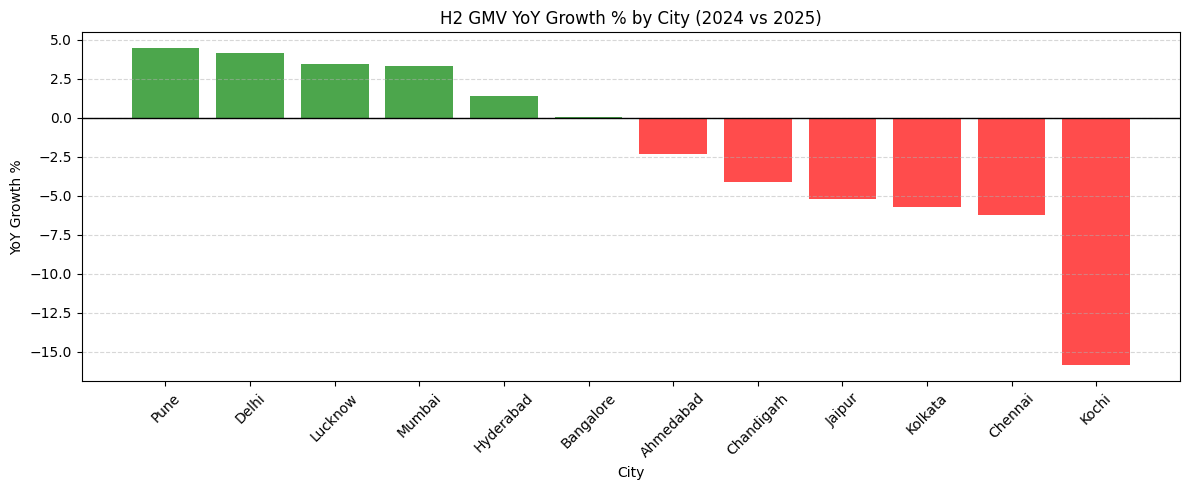

In [15]:
city_compare_sorted = city_compare.sort_values("YoY_pct", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))

# Color green for positive, red for negative
colors = ["green" if x > 0 else "red" for x in city_compare_sorted["YoY_pct"]]

ax.bar(city_compare_sorted["city"], city_compare_sorted["YoY_pct"], 
       color=colors, alpha=0.7)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("H2 GMV YoY Growth % by City (2024 vs 2025)")
ax.set_xlabel("City")
ax.set_ylabel("YoY Growth %")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

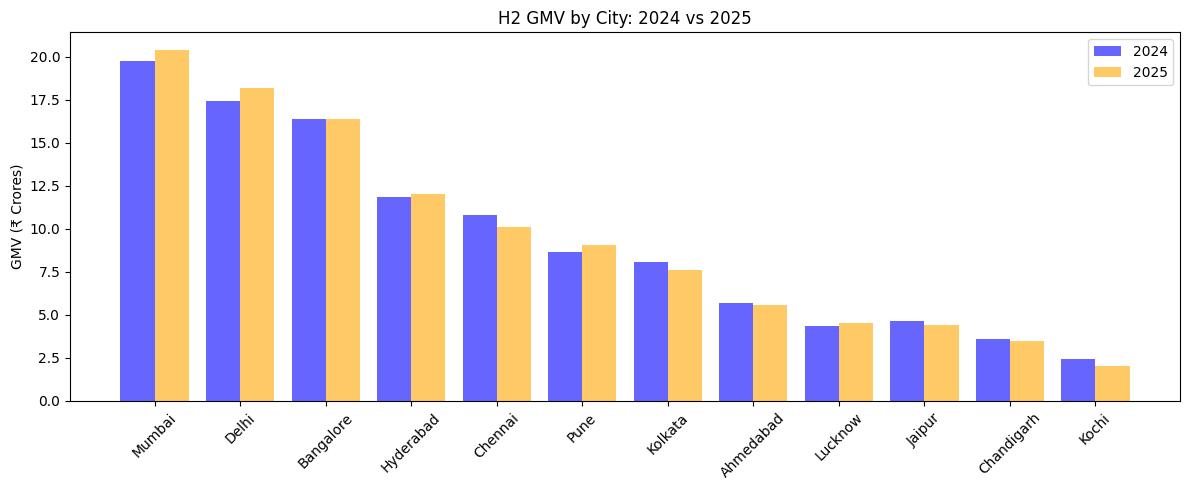

In [16]:
city_compare_sorted = city_compare.sort_values("GMV_2025", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5))

x = range(len(city_compare_sorted))
ax1.bar([i - 0.2 for i in x], city_compare_sorted["GMV_2024"]/1e7, 
        width=0.4, color="blue", alpha=0.6, label="2024")
ax1.bar([i + 0.2 for i in x], city_compare_sorted["GMV_2025"]/1e7, 
        width=0.4, color="orange", alpha=0.6, label="2025")
ax1.set_ylabel("GMV (₹ Crores)")
ax1.set_xticks(x)
ax1.set_xticklabels(city_compare_sorted["city"], rotation=45)
ax1.legend(loc="upper right")

plt.title("H2 GMV by City: 2024 vs 2025")
plt.tight_layout()
plt.show()

In [17]:
# 3. GMV by category
monthly_gmv.groupby(["category"])["GMV"].sum().sort_values(ascending=False)


category
Electronics       2.565817e+09
Home & Kitchen    4.932166e+08
Fashion           2.476219e+08
Grocery           4.583056e+07
Books             3.950810e+07
Name: GMV, dtype: float64

In [18]:
# Category GMV
h2_months = [7, 8, 9, 10, 11, 12]

# H2 2024 category GMV
h2_2024_cat = (final_df[(final_df["order_year"] == 2024) & 
                         (final_df["order_month"].isin(h2_months))]
               .groupby("category")["GMV"]
               .sum()
               .reset_index()
               .rename(columns={"GMV":"GMV_2024"}))

# H2 2025 category GMV
h2_2025_cat = (final_df[(final_df["order_year"] == 2025) & 
                         (final_df["order_month"].isin(h2_months))]
               .groupby("category")["GMV"]
               .sum()
               .reset_index()
               .rename(columns={"GMV":"GMV_2025"}))

# Merge and YoY
cat_compare = pd.merge(h2_2024_cat, h2_2025_cat, on="category")
cat_compare["YoY_pct"] = ((cat_compare["GMV_2025"] - 
                            cat_compare["GMV_2024"]) / 
                            cat_compare["GMV_2024"] * 100).round(2)
cat_compare = cat_compare.sort_values("YoY_pct", ascending=False)

print("H2 Category GMV Comparison")
print(cat_compare)

# 2025 full year category GMV
gmv_2025_cat = (final_df[final_df["order_year"] == 2025]
                .groupby(["order_month","order_monthname","category"])["GMV"]
                .sum()
                .reset_index()
                .sort_values("order_month"))

print("\n2025 Monthly GMV by Category")
print(gmv_2025_cat)

H2 Category GMV Comparison
         category     GMV_2024     GMV_2025  YoY_pct
1     Electronics  859631440.0  863915046.0     0.50
2         Fashion   83124315.0   83228470.0     0.13
3         Grocery   15456940.0   15339241.0    -0.76
4  Home & Kitchen  165940559.0  162538413.0    -2.05
0           Books   13514431.0   13120677.0    -2.91

2025 Monthly GMV by Category
    order_month order_monthname        category          GMV
0             1         January           Books    2243350.0
1             1         January     Electronics  143589731.0
2             1         January         Fashion   13551591.0
3             1         January         Grocery    2514574.0
4             1         January  Home & Kitchen   28012439.0
5             2        February           Books    1977239.0
6             2        February     Electronics  133407472.0
7             2        February         Fashion   12473756.0
8             2        February         Grocery    2414064.0
9             2

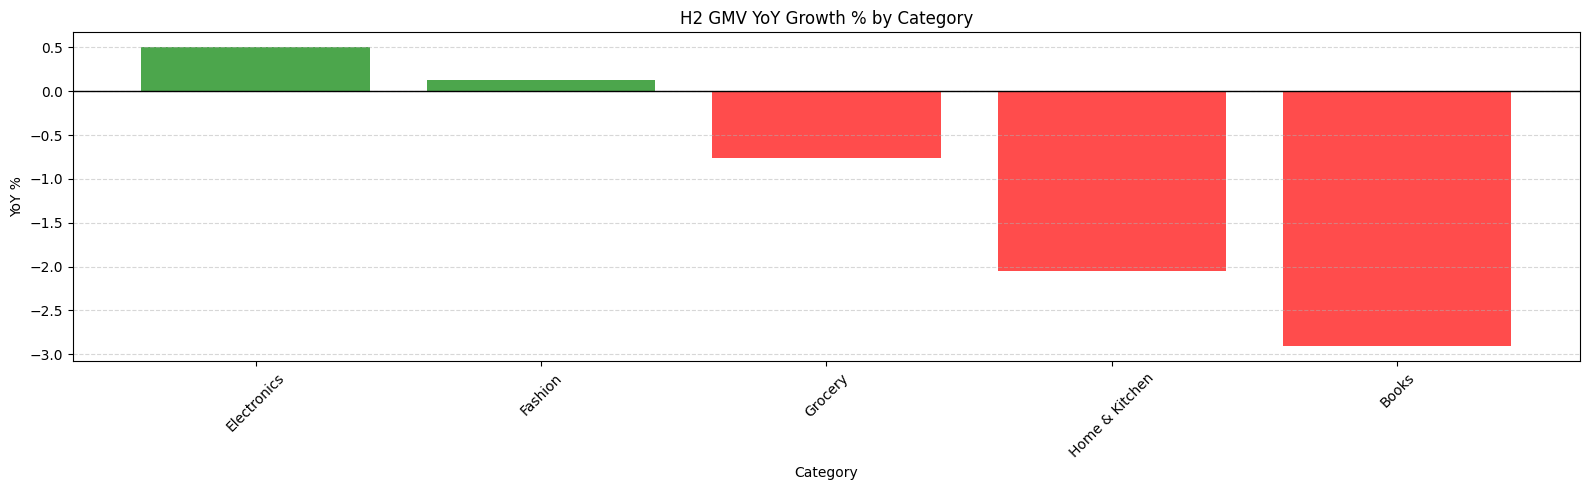

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

# YoY % bar
colors = ["green" if x > 0 else "red" for x in cat_compare["YoY_pct"]]
ax.bar(cat_compare["category"], cat_compare["YoY_pct"],
       color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("H2 GMV YoY Growth % by Category")
ax.set_xlabel("Category")
ax.set_ylabel("YoY %")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

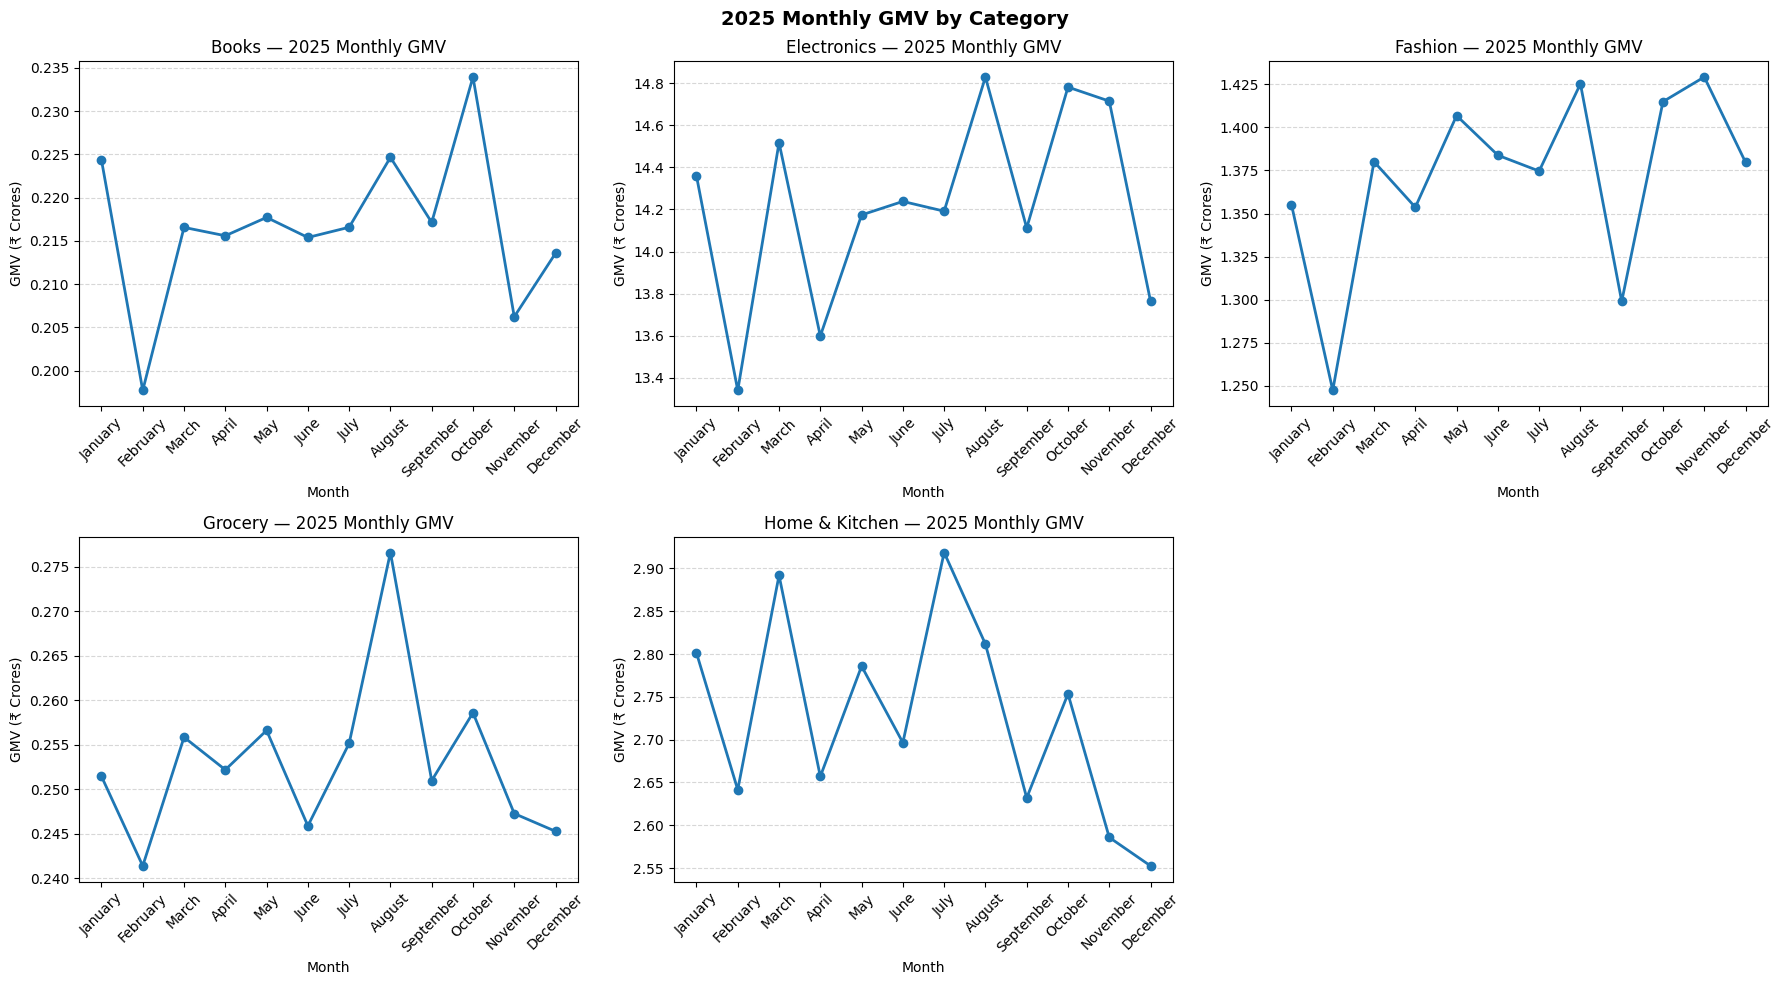

In [20]:
categories = gmv_2025_cat["category"].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_data = gmv_2025_cat[gmv_2025_cat["category"] == cat]
    axes[i].plot(cat_data["order_monthname"], cat_data["GMV"]/1e7,
                 marker="o", linewidth=2)
    axes[i].set_title(f"{cat} — 2025 Monthly GMV")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("GMV (₹ Crores)")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Hide the last empty subplot (5 categories, 6 subplots)
axes[5].set_visible(False)

plt.suptitle("2025 Monthly GMV by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
city_cat = final_df[final_df["order_year"] == 2025].groupby(["city","category"])["GMV"].sum().unstack(fill_value=0)


In [22]:
# 4. GMV by city + category (which city buys what)
city_cat

category,Books,Electronics,Fashion,Grocery,Home & Kitchen
city,,,,,
Ahmedabad,1215448.0,88624761.0,8112135.0,1526622.0,16072144.0
Bangalore,3716714.0,244376229.0,23505419.0,4254078.0,46608363.0
Chandigarh,768654.0,52370133.0,5029462.0,993918.0,9570328.0
Chennai,2396945.0,151455487.0,14268375.0,2817893.0,27461893.0
Delhi,3994851.0,273836886.0,26479641.0,4747413.0,51731132.0
Hyderabad,2492624.0,175956992.0,17099156.0,2972530.0,34128522.0
Jaipur,1013578.0,66722794.0,7276973.0,1272670.0,13733793.0
Kochi,521777.0,32802170.0,2907015.0,543887.0,5824542.0
Kolkata,1884296.0,112730913.0,11392890.0,2107237.0,22613306.0


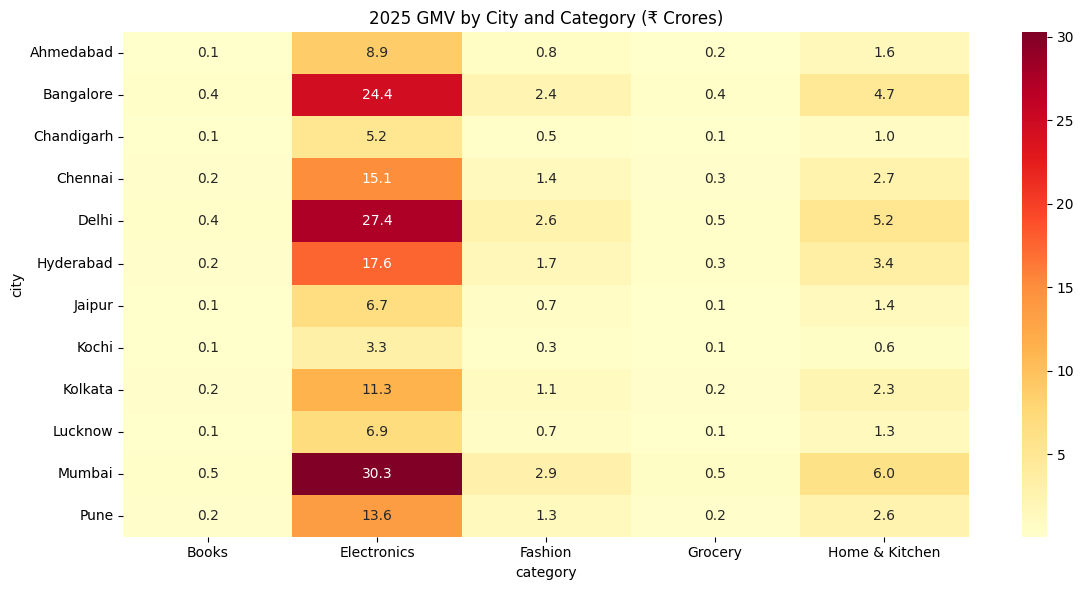

In [23]:
import seaborn as sns
city_cat_cr = city_cat / 1e7 
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(city_cat_cr, annot=True, fmt=".1f", 
            cmap="YlOrRd", ax=ax)
ax.set_title("2025 GMV by City and Category (₹ Crores)")
plt.tight_layout()
plt.show()

In [24]:
orders_1

,order_id,customer_id,created_at,order_year,order_monthname,order_month,status
0,ORD000001,C08689,2024-07-01,2024,July,7,Delivered
2,ORD000003,C10589,2024-07-01,2024,July,7,Delivered
3,ORD000004,C11558,2024-07-01,2024,July,7,Delivered
4,ORD000005,C05977,2024-07-01,2024,July,7,Delivered
5,ORD000006,C00994,2024-07-01,2024,July,7,Delivered
...,...,...,...,...,...,...,...
99997,ORD099998,C17891,2025-12-30,2025,December,12,Delivered
99989,ORD099990,C13779,2025-12-30,2025,December,12,Delivered
99978,ORD099979,C14059,2025-12-30,2025,December,12,Delivered
99995,ORD099996,C20036,2025-12-30,2025,December,12,Returned


In [25]:
orders_1 = orders[["order_id","customer_id", "created_at", "status",
    "order_year", "order_month", "order_monthname",
    "customer_order_num"
]].copy()

# 1. Sort
orders_1 = orders_1.sort_values(["customer_id", "created_at"])

# 2. Flags
orders_1["delivered_flag"] = (orders_1["status"] == "Delivered").astype(int)
orders_1["bad_flag"] = orders_1["status"].isin(["Cancelled", "Returned"]).astype(int)

# 3. Cumulative delivered per customer
orders_1["cum_delivered"] = (
    orders_1.groupby("customer_id")["delivered_flag"].cumsum()
)

# 4. Customer-Month level (ONE row per customer per month)
cust_month = (
    orders_1.groupby(["customer_id", "order_year", "order_month", "order_monthname"])
    .agg(
        first_order_num=("customer_order_num", "min"),
        max_cum_delivered=("cum_delivered", "max")
    )
    .reset_index()
)

# 5. Mutually exclusive flags
cust_month["is_first"] = (cust_month["first_order_num"] == 1).astype(int)
cust_month["is_repeat"] = (cust_month["max_cum_delivered"] >= 2).astype(int)

# Ensure NO overlap (repeat overrides first)
cust_month["is_first"] = cust_month["is_first"] * (1 - cust_month["is_repeat"])

# 6. Monthly aggregation
final = (
    cust_month.groupby(["order_year", "order_month", "order_monthname"])
    .agg(
        total_customers=("customer_id", "nunique"),
        first_time_customers=("is_first", "sum"),
        repeat_customers=("is_repeat", "sum")
    )
    .reset_index()
)

# 7. Add total orders + bad orders from original table
orders_monthly = (
    orders_1.groupby(["order_year", "order_month", "order_monthname"])
    .agg(
        total_orders=("order_id", "nunique"),
        bad_orders=("bad_flag", "sum")
    )
    .reset_index()
)

# 8. Merge
final = final.merge(
    orders_monthly,
    on=["order_year", "order_month", "order_monthname"],
    how="left"
)

# 9. Rates
final["repeat_purchase_rate"] = (
    final["repeat_customers"] / final["total_customers"] * 100
).round(2)

final["first_purchase_rate"] = (
    final["first_time_customers"] / final["total_customers"] * 100
).round(2)

final["bad_order_rate"] = (
    final["bad_orders"] / final["total_orders"] * 100
).round(2)

# 10. Sort properly
final = final.sort_values(["order_year", "order_month"]).reset_index(drop=True)

In [26]:
monthly_orders = final.copy()

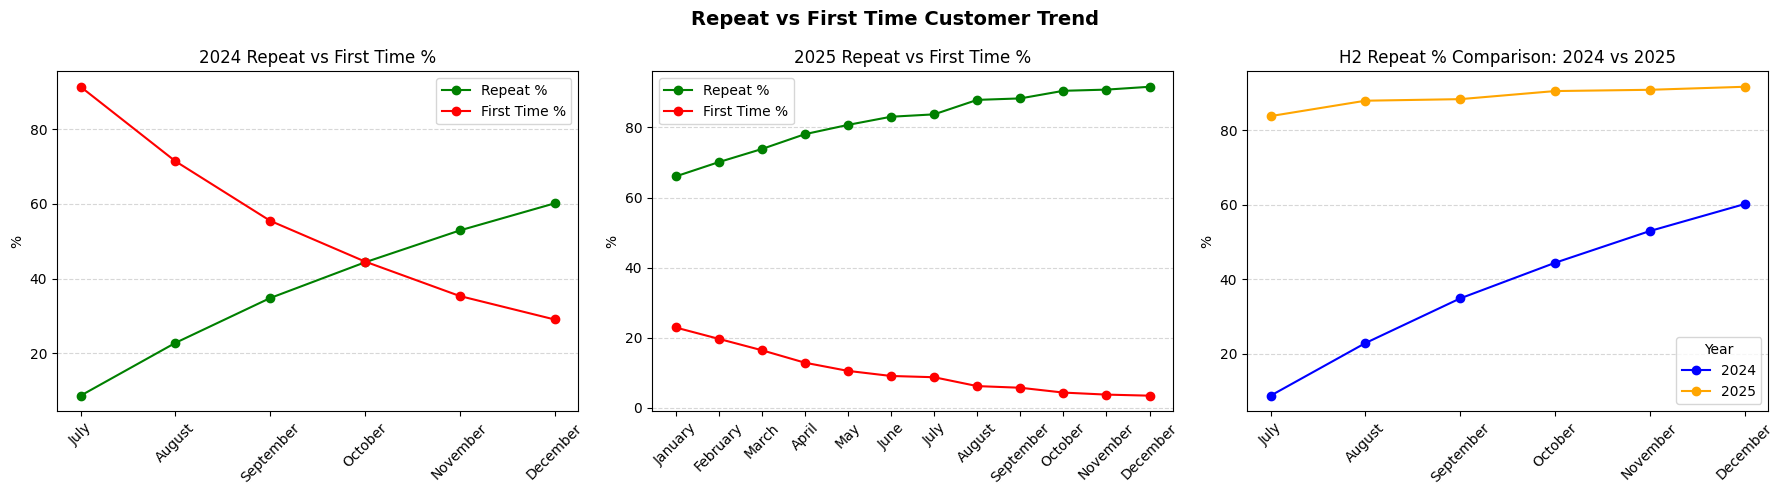

In [27]:
h2_months = [7, 8, 9, 10, 11, 12]
data_2024 = monthly_orders[monthly_orders["order_year"] == 2024]
data_2025 = monthly_orders[monthly_orders["order_year"] == 2025]
h2_2024   = data_2024[data_2024["order_month"].isin(h2_months)]
h2_2025   = data_2025[data_2025["order_month"].isin(h2_months)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - 2024
axes[0].plot(data_2024["order_monthname"], data_2024["repeat_purchase_rate"],
             marker="o", color="green", label="Repeat %")
axes[0].plot(data_2024["order_monthname"], data_2024["first_purchase_rate"],
             marker="o", color="red", label="First Time %")
axes[0].set_title("2024 Repeat vs First Time %")
axes[0].set_ylabel("%")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2 - 2025
axes[1].plot(data_2025["order_monthname"], data_2025["repeat_purchase_rate"],
             marker="o", color="green", label="Repeat %")
axes[1].plot(data_2025["order_monthname"], data_2025["first_purchase_rate"],
             marker="o", color="red", label="First Time %")
axes[1].set_title("2025 Repeat vs First Time %")
axes[1].set_ylabel("%")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 3 - H2 Comparison
axes[2].plot(h2_2024["order_monthname"], h2_2024["repeat_purchase_rate"],
             marker="o", color="blue", label="2024")
axes[2].plot(h2_2025["order_monthname"], h2_2025["repeat_purchase_rate"],
             marker="o", color="orange", label="2025")
axes[2].set_title("H2 Repeat % Comparison: 2024 vs 2025")
axes[2].set_ylabel("%")
axes[2].legend(title="Year")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Repeat vs First Time Customer Trend", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
monthly_orders

,order_year,order_month,order_monthname,total_customers,first_time_customers,repeat_customers,total_orders,bad_orders,repeat_purchase_rate,first_purchase_rate,bad_order_rate
0,2024,7,July,4947,4516,431,5634,777,8.71,91.29,13.79
1,2024,8,August,4890,3491,1116,5551,701,22.82,71.39,12.63
2,2024,9,September,4930,2734,1716,5595,737,34.81,55.46,13.17
3,2024,10,October,5102,2274,2263,5791,772,44.36,44.57,13.33
4,2024,11,November,4849,1714,2564,5504,695,52.88,35.35,12.63
5,2024,12,December,4952,1440,2977,5719,773,60.12,29.08,13.52
6,2025,1,January,4898,1122,3233,5604,693,66.01,22.91,12.37
7,2025,2,February,4581,901,3211,5163,641,70.09,19.67,12.42
8,2025,3,March,4964,815,3665,5627,710,73.83,16.42,12.62
9,2025,4,April,4866,626,3799,5515,727,78.07,12.86,13.18


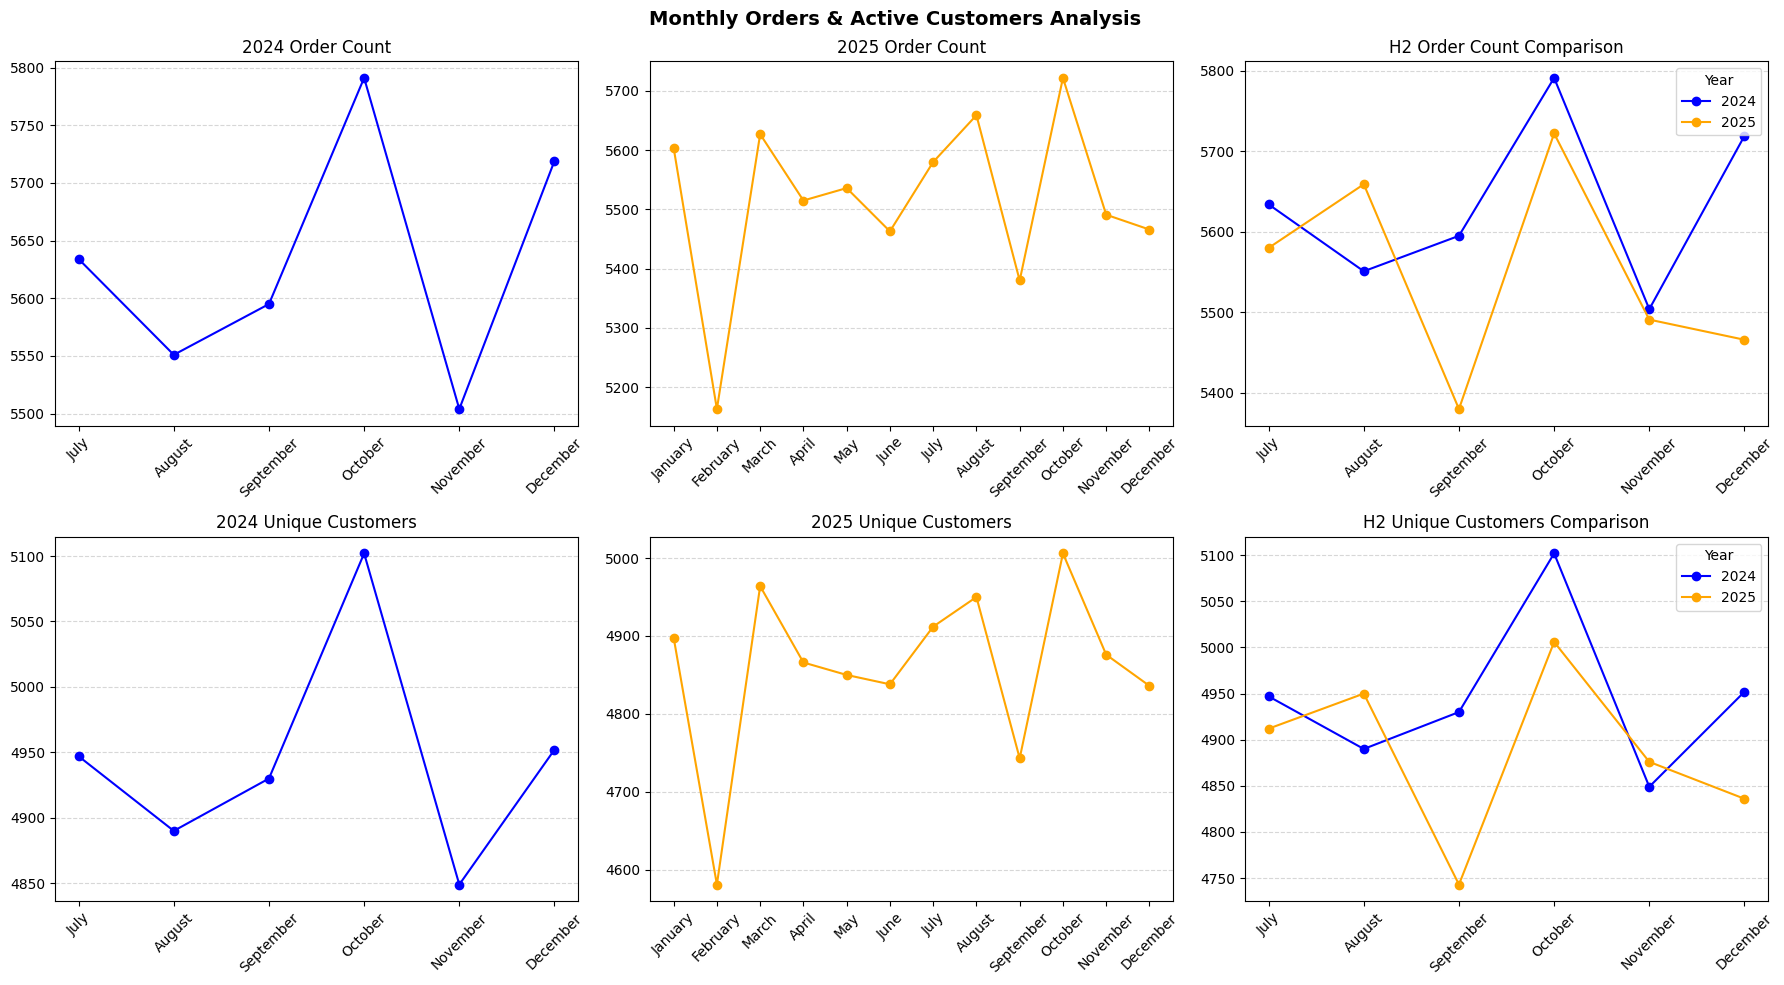

In [29]:
h2_months = [7, 8, 9, 10, 11, 12]

data_2024 = monthly_orders[monthly_orders["order_year"] == 2024]
data_2025 = monthly_orders[monthly_orders["order_year"] == 2025]
h2_2024   = data_2024[data_2024["order_month"].isin(h2_months)]
h2_2025   = data_2025[data_2025["order_month"].isin(h2_months)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1 - Order Count
axes[0,0].plot(data_2024["order_monthname"], data_2024["total_orders"], marker="o", color="blue")
axes[0,0].set_title("2024 Order Count")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].grid(axis="y", linestyle="--", alpha=0.5)

axes[0,1].plot(data_2025["order_monthname"], data_2025["total_orders"], marker="o", color="orange")
axes[0,1].set_title("2025 Order Count")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].grid(axis="y", linestyle="--", alpha=0.5)

axes[0,2].plot(h2_2024["order_monthname"], h2_2024["total_orders"], marker="o", color="blue",   label="2024")
axes[0,2].plot(h2_2025["order_monthname"], h2_2025["total_orders"], marker="o", color="orange", label="2025")
axes[0,2].set_title("H2 Order Count Comparison")
axes[0,2].legend(title="Year")
axes[0,2].tick_params(axis="x", rotation=45)
axes[0,2].grid(axis="y", linestyle="--", alpha=0.5)

# Row 2 - Unique Customers
axes[1,0].plot(data_2024["order_monthname"], data_2024["total_customers"], marker="o", color="blue")
axes[1,0].set_title("2024 Unique Customers")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1,1].plot(data_2025["order_monthname"], data_2025["total_customers"], marker="o", color="orange")
axes[1,1].set_title("2025 Unique Customers")
axes[1,1].tick_params(axis="x", rotation=45)
axes[1,1].grid(axis="y", linestyle="--", alpha=0.5)

axes[1,2].plot(h2_2024["order_monthname"], h2_2024["total_customers"], marker="o", color="blue",   label="2024")
axes[1,2].plot(h2_2025["order_monthname"], h2_2025["total_customers"], marker="o", color="orange", label="2025")
axes[1,2].set_title("H2 Unique Customers Comparison")
axes[1,2].legend(title="Year")
axes[1,2].tick_params(axis="x", rotation=45)
axes[1,2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Monthly Orders & Active Customers Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# Need shipment + orders + customers merged
shipment_2 = shipments[["order_id", "carrier", "ship_to_city", "delivery_status", "shipping_cost", "diff_hours"]]
orders_3   = orders[["order_id", "customer_id", "order_year", "order_month", "order_monthname"]]
customer_2 = customers[["customer_id", "city"]]

# Merge
orders_city = pd.merge(orders_3, customer_2, on="customer_id", how="left")
delay_df    = pd.merge(shipment_2, orders_city, on="order_id", how="left")

# Delay flag
delay_df["is_delayed"] = delay_df["delivery_status"].isin(["Late_1_2d", "Late_3_5d", "Late_5p", "Lost"]).astype(int)

# 1. Delay by City
print("Delay % by City")
delay_city = (delay_df.groupby("city")
              .agg(total=("order_id", "count"),
                   delayed=("is_delayed", "sum"))
              .reset_index())
delay_city["delay_pct"] = ((delay_city["delayed"] / delay_city["total"]) * 100).round(2)
print(delay_city.sort_values("delay_pct", ascending=False))

# 2. Delay by Carrier
print("\nDelay % by Carrier")
delay_carrier = (delay_df.groupby("carrier")
                 .agg(total=("order_id", "count"),
                      delayed=("is_delayed", "sum"))
                 .reset_index())
delay_carrier["delay_pct"] = ((delay_carrier["delayed"] / delay_carrier["total"]) * 100).round(2)
print(delay_carrier.sort_values("delay_pct", ascending=False))

# 3. Delay by City + Carrier combined
print("\nDelay % by City + Carrier")
delay_city_carrier = (delay_df.groupby(["city", "carrier"])
                      .agg(total=("order_id", "count"),
                           delayed=("is_delayed", "sum"))
                      .reset_index())
delay_city_carrier["delay_pct"] = ((delay_city_carrier["delayed"] / 
                                     delay_city_carrier["total"]) * 100).round(2)
print(delay_city_carrier.sort_values("delay_pct", ascending=False).head(10))

Delay % by City
          city  total  delayed  delay_pct
6       Jaipur   3818     1873      49.06
9      Lucknow   3675     1785      48.57
8      Kolkata   6431     2678      41.64
0    Ahmedabad   4497     1199      26.66
11        Pune   7221     1913      26.49
2   Chandigarh   2846      753      26.46
3      Chennai   8346     2206      26.43
7        Kochi   1767      445      25.18
1    Bangalore  13023     2589      19.88
4        Delhi  14587     2888      19.80
5    Hyderabad   9360     1846      19.72
10      Mumbai  16423     3094      18.84

Delay % by Carrier
     carrier  total  delayed  delay_pct
1  Delhivery  29539     9364      31.70
2      Ekart  21840     6772      31.01
0   BlueDart  21906     5755      26.27
3    InHouse  18709     1378       7.37

Delay % by City + Carrier
          city    carrier  total  delayed  delay_pct
22      Jaipur  Delhivery   1542     1270      82.36
31     Lucknow  Delhivery   1462     1199      82.01
29     Kolkata      Ekart   1917

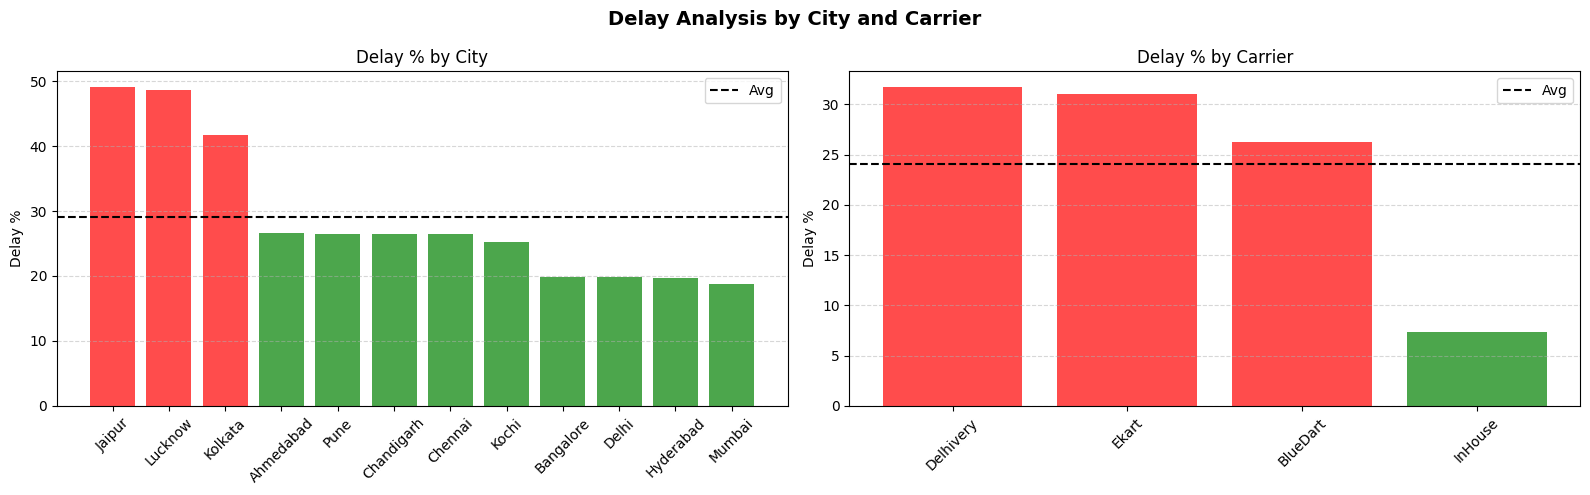

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# City delay %
colors_city = ["red" if x > delay_city["delay_pct"].mean() 
               else "green" for x in delay_city.sort_values("delay_pct", ascending=False)["delay_pct"]]
axes[0].bar(delay_city.sort_values("delay_pct", ascending=False)["city"],
            delay_city.sort_values("delay_pct", ascending=False)["delay_pct"],
            color=colors_city, alpha=0.7)
axes[0].axhline(delay_city["delay_pct"].mean(), color="black", linestyle="--", label="Avg")
axes[0].set_title("Delay % by City")
axes[0].set_ylabel("Delay %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Carrier delay %
colors_carrier = ["red" if x > delay_carrier["delay_pct"].mean() 
                  else "green" for x in delay_carrier.sort_values("delay_pct", ascending=False)["delay_pct"]]
axes[1].bar(delay_carrier.sort_values("delay_pct", ascending=False)["carrier"],
            delay_carrier.sort_values("delay_pct", ascending=False)["delay_pct"],
            color=colors_carrier, alpha=0.7)
axes[1].axhline(delay_carrier["delay_pct"].mean(), color="black", linestyle="--", label="Avg")
axes[1].set_title("Delay % by Carrier")
axes[1].set_ylabel("Delay %")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Delay Analysis by City and Carrier", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [32]:
delay_df.to_csv(r"../Data/analysis_data/delay_by_city_carrier.csv",index=False)
monthly_orders.to_csv(r"../Data/analysis_data/monthly_orders_unique_rep_firsttime_cust.csv",index=False)
cust_month.to_csv(r"../Data/analysis_data/customer_retention_raw.csv",index=False)
city_compare.to_csv(r"..\Data\analysis_data\city_compare_gmv.csv",index=False)
monthly_gmv_trend.to_csv(r"..\Data\analysis_data\monthly_gmv_trend.csv",index=False)
monthly_gmv.to_csv(r"..\Data\analysis_data\GMV_BY_YEAR_MONTH_CITY_CATEGORY.csv",index=False)


In [33]:
# In your notebook, create this master file
master_df = final_df[[ 
    # Order identifiers
    "order_id",
    "order_item_id",
    
    # Time
    "created_at",
    "order_year",
    "order_month",
    "order_monthname",
    
    # Customer
    "customer_id",
    "city",
    "segment",
    
    # Product
    "product_id",
    "category",
    
    # Financials
    "GMV",
    "discount_amount",
    "net_GMV",
    "platform_revenue",
    
    # Order status
    "status",
    "payment_method",
    "is_fast_delivery_eligible",
    
    # Customer behavior
    "is_first_order",
    "is_repeat",
    "bad_order_count",
    
    # Shipment
    "carrier",
    "delivery_status",
    "ship_from_city",
    "ship_to_city",
    "shipping_cost",
    "diff_hours",
    "route_covered"
]].copy()


KeyError: "['segment', 'discount_amount', 'net_GMV', 'platform_revenue', 'payment_method', 'is_fast_delivery_eligible', 'is_first_order', 'is_repeat', 'bad_order_count', 'carrier', 'delivery_status', 'ship_from_city', 'ship_to_city', 'shipping_cost', 'diff_hours', 'route_covered'] not in index"

In [34]:
df = final_df.copy()

In [35]:
cus = customers[["customer_id","signup_year","segment","signup_month"]]
ords = orders[["order_id","customer_id","promised_delivery_date","is_fast_delivery_eligible","payment_method","customer_type"]]
ord_itsm = order_items[["order_item_id","order_id","product_id","platform_revenue","discount_amount","net_GMV","seller_id"]]
sls = sellers[["seller_id","seller_name","primary_city","rating_bin"]]
ships = shipments[["shipment_id","order_id","carrier","shipping_cost","delivery_status","diff_hours","route_covered","shipped_date","delivered_date"]]

In [36]:
final_df = pd.merge(final_df,monthly_orders,on=["order_year","order_year","order_monthname"],how="left")
final_df = pd.merge(final_df,cus,on=["customer_id"],how='left')
final_df = pd.merge(final_df,ords,on=["order_id","customer_id"],how='left')
final_df = pd.merge(final_df,ord_itsm,on=["order_id","order_item_id","product_id"],how='left')

final_df = pd.merge(final_df,ships,on=["order_id"],how='left')

In [37]:
final_df = pd.merge(final_df,sls,on=["seller_id"],how='left')

In [39]:
master_df = final_df[[
    # identifiers
    "order_id",
    "order_item_id",
    
    # time
    "created_at",
    "order_year",
    "order_month_x",
    "order_monthname",
    
    # customer
    "customer_id",
    "city",
    "segment",
    "customer_type",
    
    # product
    "category",
    
    # financials — safe to sum (order_item level)
    "GMV",
    "platform_revenue",
    "discount_amount",
    "net_GMV",
    
    # order info
    "status",
    "payment_method",
    "is_fast_delivery_eligible",
    
    # shipment
    "carrier",
    "delivery_status",
    "shipping_cost",
    "diff_hours",
    "route_covered",
    
    # seller
    "seller_id",
    "rating_bin",

]].rename(columns={"order_month_x": "order_month"})

In [42]:
master_df.dtypes

order_id                                str
order_item_id                           str
created_at                   datetime64[us]
order_year                            int32
order_month                           int32
order_monthname                         str
customer_id                             str
city                                    str
segment                                 str
customer_type                           str
category                                str
GMV                                 float64
platform_revenue                    float64
discount_amount                     float64
net_GMV                             float64
status                                  str
payment_method                          str
is_fast_delivery_eligible              bool
carrier                                 str
delivery_status                         str
shipping_cost                       float64
diff_hours                          float64
route_covered                   

In [43]:
master_df.to_csv(r"../Data/analysis_data/master.csv",index=False)

In [45]:
master_df["customer_type"].value_counts()

customer_type
repeat    129263
first      40666
Name: count, dtype: int64